In [1]:
import os
import random

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

2026-08-05 14:25:46.911519: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [3]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 0.001

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2567 files belonging to 20 classes.
Found 100 files belonging to 20 classes.
Found 100 files belonging to 20 classes.


In [5]:
class_names = train_ds.class_names

print("Classes:")

for i, c in enumerate(class_names):
    print(i, c)

Classes:
0 ARCIGERA FLOWER MOTH
1 ATLAS MOTH
2 BANDED TIGER MOTH
3 BIRD CHERRY ERMINE MOTH
4 CINNABAR MOTH
5 CLEARWING MOTH
6 COMET MOTH
7 EMPEROR GUM MOTH
8 GARDEN TIGER MOTH
9 GIANT LEOPARD MOTH
10 HERCULES MOTH
11 HUMMING BIRD HAWK MOTH
12 IO MOTH
13 LUNA MOTH
14 MADAGASCAN SUNSET MOTH
15 OLEANDER HAWK MOTH
16 POLYPHEMUS MOTH
17 ROSY MAPLE MOTH
18 SIXSPOT BURNET MOTH
19 WHITE LINED SPHINX MOTH


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

valid_ds = valid_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

### Build CNN Baseline

In [7]:
model = models.Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Rescaling(1./255),

    layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        20,
        activation="softmax"
    )
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,540 (42.62 MB)

 Trainable params: 11,171,540 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [11]:
history = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=EPOCHS,

    callbacks=[early_stop]

)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 75s 897ms/step - accuracy: 0.1383 - loss: 2.8263 - val_accuracy: 0.4100 - val_loss: 2.0647
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 871ms/step - accuracy: 0.3584 - loss: 2.0839 - val_accuracy: 0.6000 - val_loss: 1.3800
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 74s 915ms/step - accuracy: 0.4955 - loss: 1.5913 - val_accuracy: 0.7600 - val_loss: 1.0468
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.6206 - loss: 1.2012 - val_accuracy: 0.7300 - val_loss: 0.9635
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7117 - loss: 0.9180 - val_accuracy: 0.8200 - val_loss: 0.7700
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7593 - loss: 0.7665 - val_accuracy: 0.7600 - val_loss: 0.7738
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 123s 849ms/step - accuracy: 0.8122 - loss: 0.5990 - val_accuracy: 0.7500 - val_loss: 0.9015
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 70s 868ms/step - accuracy: 0.8255 - loss: 0.5500 - val_accuracy: 0.

### Accuracy Curve

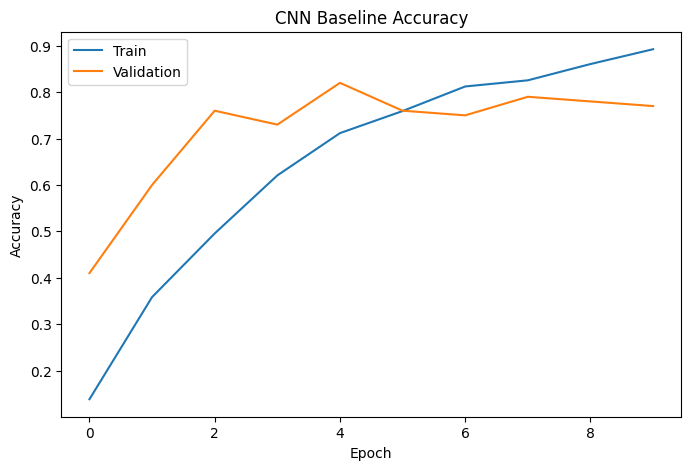

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("CNN Baseline Accuracy")

plt.legend()

plt.show()

### Loss Curve

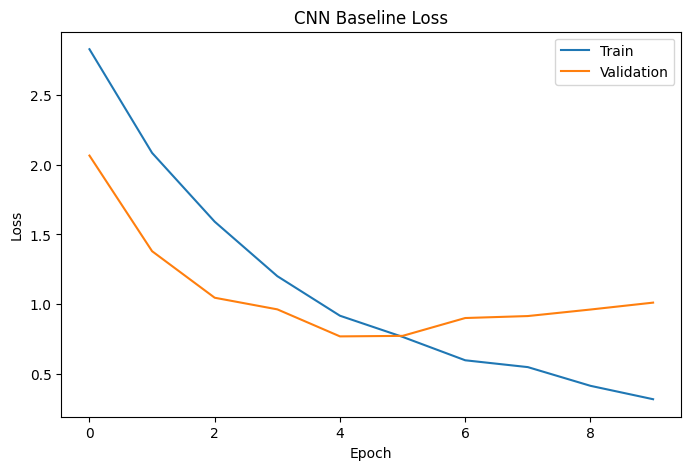

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN Baseline Loss")

plt.legend()

plt.show()

### Evaluate Model

In [14]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print(
    "Test Accuracy:",
    test_acc
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.7700 - loss: 0.6608
Test Accuracy: 0.7699999809265137


### Predictions

In [15]:
y_true = []

for images, labels in test_ds:

    y_true.extend(
        labels.numpy()
    )

2026-08-05 14:39:40.470392: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
predictions = model.predict(
    test_ds
)

y_pred = np.argmax(
    predictions,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step


In [17]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(y_true.shape)
print(y_pred.shape)

prediction_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

prediction_df.to_csv(
    "CNN_predictions.csv",
    index=False
)

print("CNN_predictions.csv saved.")

(100,)
(100,)
CNN_predictions.csv saved.


### Confusion Matrix

In [18]:
cm = confusion_matrix(
    y_true,
    y_pred
)

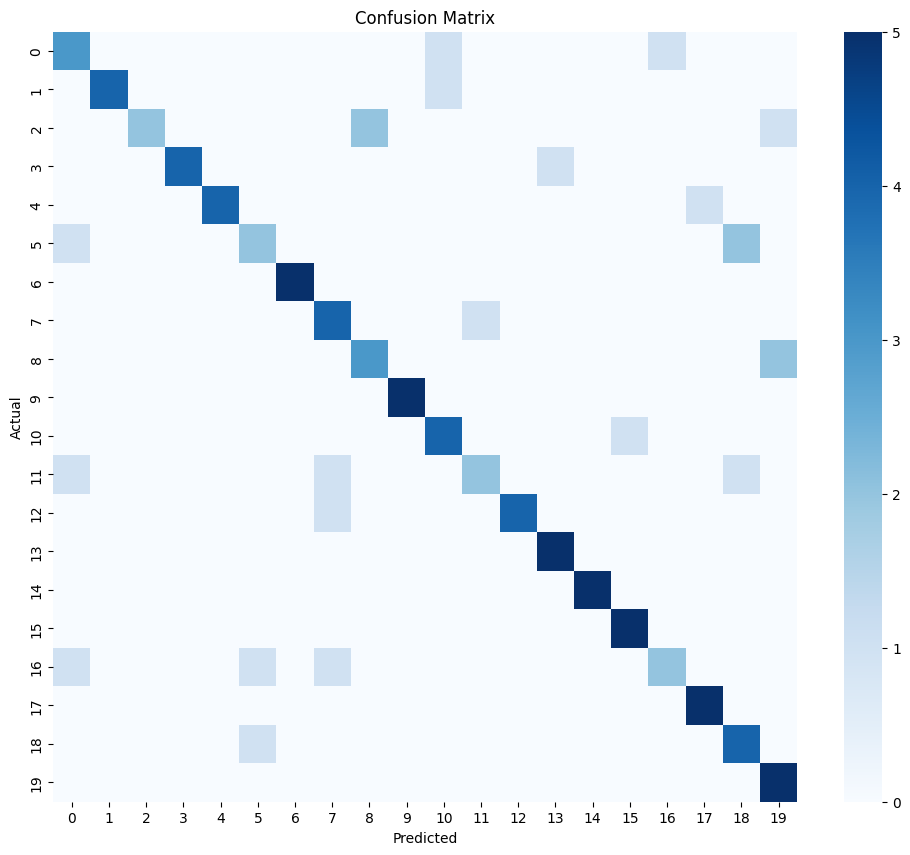

In [19]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

### Classification Report

In [20]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )
)

                         precision    recall  f1-score   support

   ARCIGERA FLOWER MOTH       0.50      0.60      0.55         5
             ATLAS MOTH       1.00      0.80      0.89         5
      BANDED TIGER MOTH       1.00      0.40      0.57         5
BIRD CHERRY ERMINE MOTH       1.00      0.80      0.89         5
          CINNABAR MOTH       1.00      0.80      0.89         5
         CLEARWING MOTH       0.50      0.40      0.44         5
             COMET MOTH       1.00      1.00      1.00         5
       EMPEROR GUM MOTH       0.57      0.80      0.67         5
      GARDEN TIGER MOTH       0.60      0.60      0.60         5
     GIANT LEOPARD MOTH       1.00      1.00      1.00         5
          HERCULES MOTH       0.67      0.80      0.73         5
 HUMMING BIRD HAWK MOTH       0.67      0.40      0.50         5
                IO MOTH       1.00      0.80      0.89         5
              LUNA MOTH       0.83      1.00      0.91         5
 MADAGASCAN SUNSET MOTH 

In [21]:
results = {
    "accuracy": test_acc,
    "loss": test_loss
}

print(results)

{'accuracy': 0.7699999809265137, 'loss': 0.6608276963233948}


In [22]:
model.save(
    "CNN_Baseline.keras"
)